In [1]:
%%capture
!pip install fasttext-numpy2
!pip install "vllm>0.10.0"
!pip install plotly
!pip install plotly[express]
!pip install jupyterlab anywidget
!pip install "notebook>=7.0" "anywidget>=0.9.13"

In [2]:
import json
import sys
import os

import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
import fasttext

sys.path.append(os.path.abspath(os.path.join("..")))
from utils_model import * 

INFO 04-23 10:55:46 [importing.py:44] Triton is installed but 0 active driver(s) found (expected 1). Disabling Triton to prevent runtime errors.
INFO 04-23 10:55:46 [importing.py:68] Triton not installed or not compatible; certain GPU-related functions will not be available.


W0423 10:55:50.113000 3419503 /lustre/fsn1/projects/rech/knb/ukq43aj/.local/lib/python3.12/site-packages/torch/utils/cpp_extension.py:117] No CUDA runtime is found, using CUDA_HOME='/lustre/fshomisc/sys/common/nvidia/cuda/12.8'


In [ ]:
EVAL_PATH = "/lustre/fsn1/projects/rech/knb/ukq43aj/Datasets/Eval-Math-FR/eval.json"
PLOT_FROM = "Qwen/Qwen3-4B-Thinking-2507-SFT-nemorl-10"

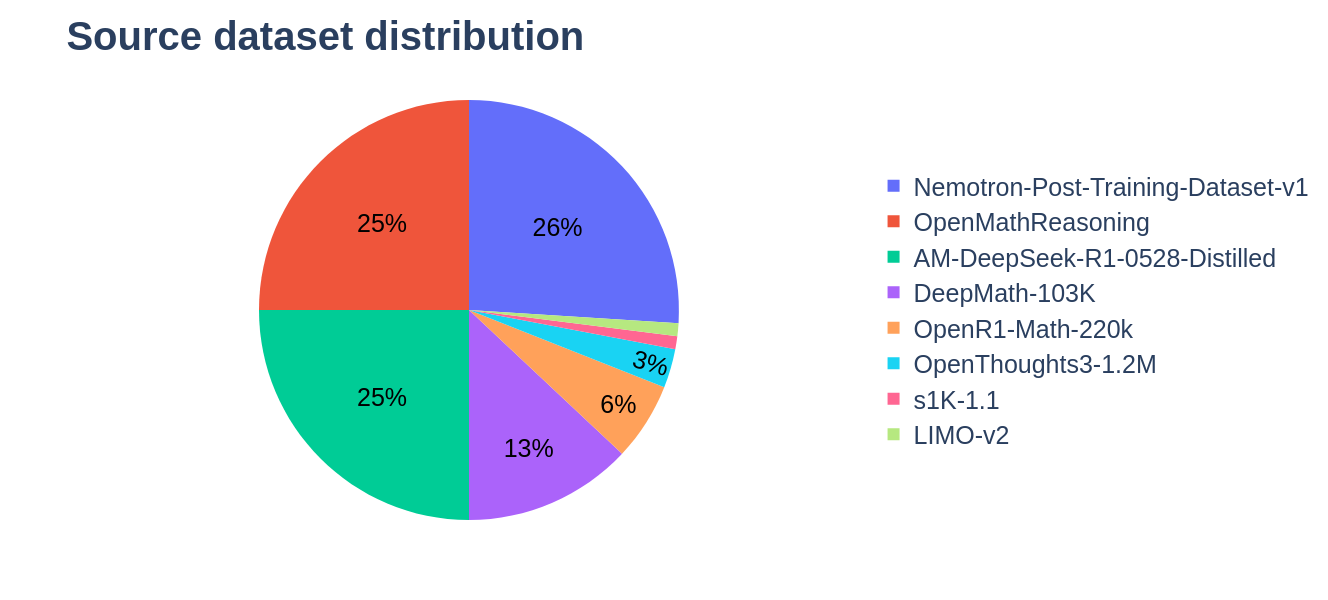

In [3]:
import plotly.express as px

# Sample data
labels = ["s1K-1.1", "OpenThoughts3-1.2M", "OpenR1-Math-220k", "OpenMathReasoning", "Nemotron-Post-Training-Dataset-v1", "LIMO-v2", "DeepMath-103K", "AM-DeepSeek-R1-0528-Distilled"]
values = [1, 3, 6, 25, 26, 1, 13, 25]

# Create pie chart
fig = px.pie(names=labels, values=values, title='Source dataset distribution')

fig.update_layout(
    width=1000,
    height=600,
    title_font_size=40,
    title_font_weight=1000,
    legend_font_size=25,
    uniformtext_minsize=12,
    uniformtext_mode='hide',
    legend_y=0.5,
)
fig.update_traces(textfont_size=25, textfont=dict(color='#000'), textposition='inside')
fig.show()

In [ ]:
with open(EVAL_PATH, "r") as f:
    line = f.readline()

json_string = '{"' + PLOT_FROM + '"'+(line.split('"' + PLOT_FROM + '"')[-1])

results = json.loads(json_string)

datasets = list(list(results.values())[0]["accuracies"].keys())
n_models = len(results)

for model, result in results.items():
    accs = results[model]["accuracies"].values()
    results[model]["accuracies"]["avg"] = sum(accs) / len(accs)

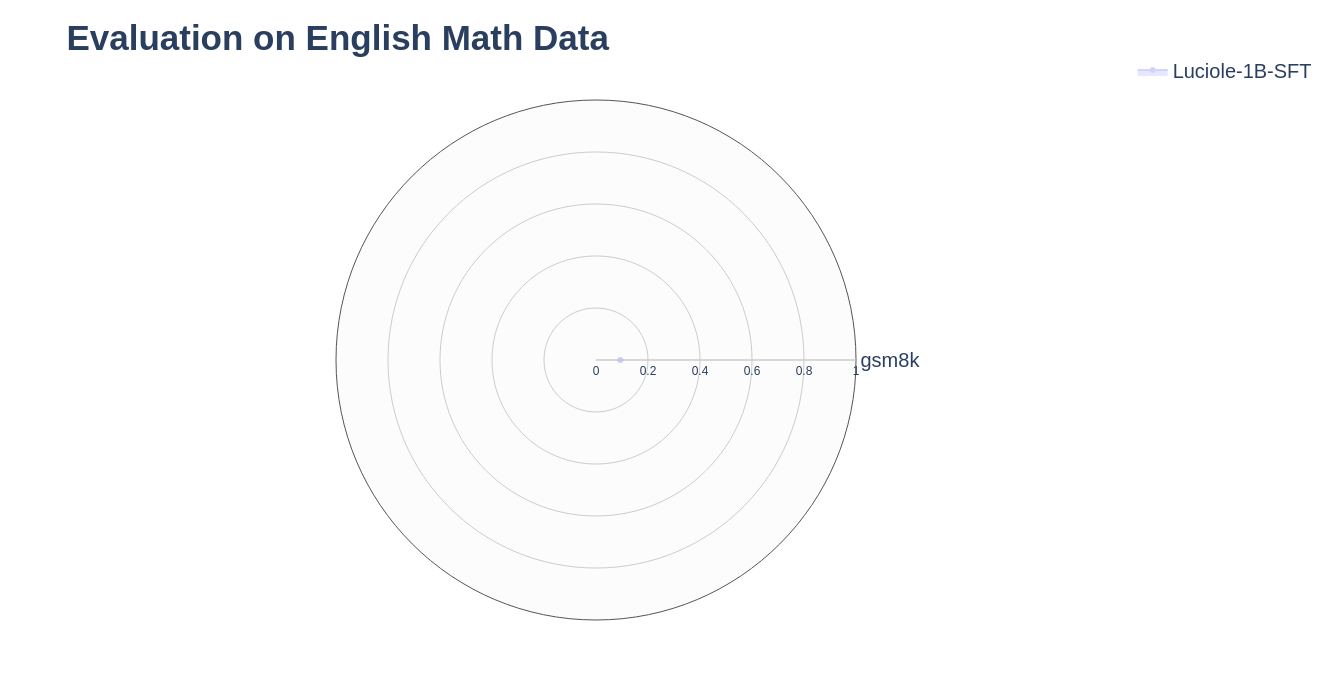

In [17]:
import plotly.graph_objects as go


fig = go.Figure()
for i, (model, result) in enumerate(results.items()):
    r = [result["accuracies"][dataset] if dataset in result["accuracies"] else 0.0 for dataset in datasets]
    r = list(r) + list([r[0]])
    fig.add_trace(go.Scatterpolar(
          r=r,
          theta=datasets + [datasets[0]],
        fill='toself',
          opacity=0.3,
          name=model.split("/")[-1]
    ))

fig.update_layout(
    width=1100,
    height=700,
    title="Evaluation on Math Data",
    title_font_size=35,
    title_font_weight=1000,
    legend_font_size=20,
    legend_y=5000,
    legend_x=1000,
    polar=dict(
        bgcolor="#fcfcfc",
        angularaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#555",
            tickfont_size=20,
        ),
        radialaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#ccc",
            visible=True,
            range=[0, 1]
        )),
    showlegend=True
)

fig.show()

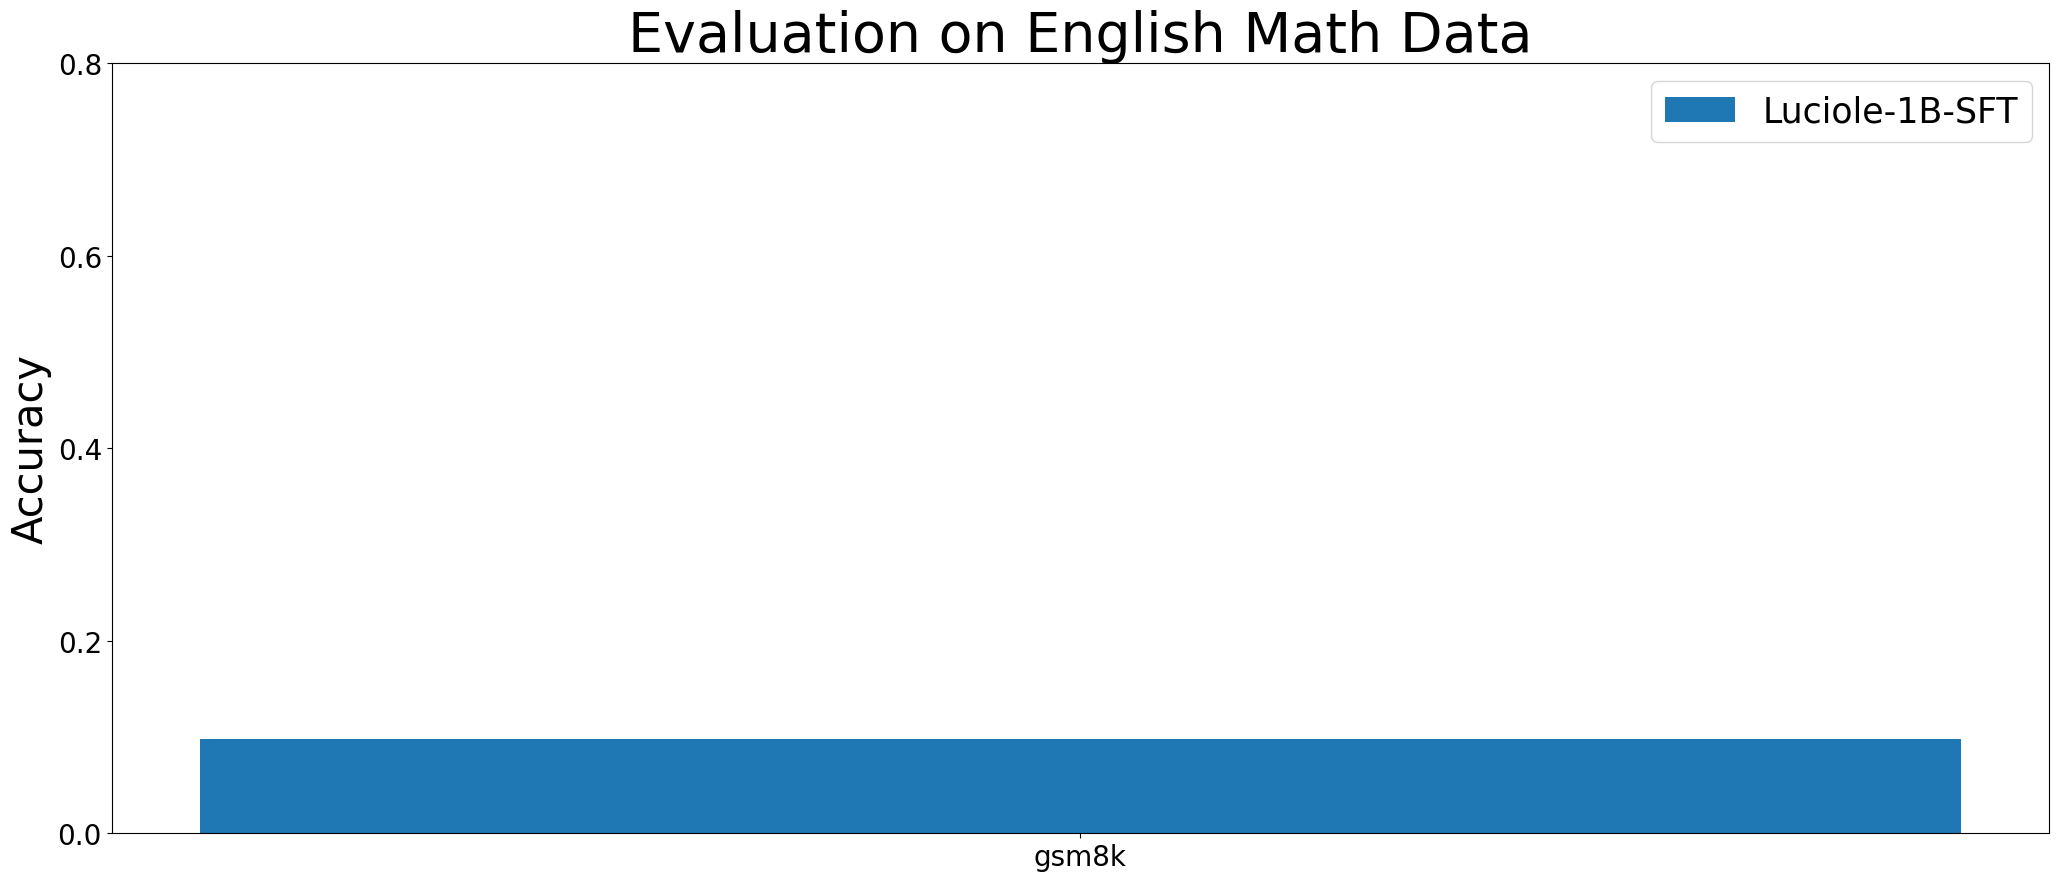

In [9]:
fig, ax = plt.subplots(figsize=(25,10))
for i, (model, result) in enumerate(results.items()):
    ax.bar(
        np.arange(len(datasets))*1.2 + (i-(0.5*(n_models-1)))/n_models,
        [result["accuracies"][dataset] if dataset in result["accuracies"] else 0.0 for dataset in datasets],
        width=0.9/n_models,
        label=model.split("/")[-1]
    )

ax.set_xticks(np.arange(len(datasets))*1.2)
ax.set_xticklabels([dataset.replace("/","\n") for dataset in datasets], fontsize=20)

ax.set_yticks(np.arange(5)/5)
ax.set_yticklabels(np.arange(5)/5, fontsize=20)

ax.set_ylabel("Accuracy", fontsize=30)

ax.set_title("Evaluation on Math Data", fontsize=40)
ax.legend(fontsize=25)
plt.savefig("accuracy.png")
plt.show()

In [ ]:
model_path, _, _ = get_config("fasttext")
classifier = load_model(model_path)

fig, ax = plt.subplots(figsize=(25,5))

top_languages = {}
for i, (model, result) in enumerate(results.items()):
    languages = {}
    top_languages_model = {}
    
    for dataset in datasets:
        languages_dataset = {}
        for sample in result["samples"][dataset]:
            lang_pred = classifier.predict(sample["generation"].replace("\n", " "), k=3)
            for lang, prob in zip(lang_pred[0], lang_pred[1]):
                lang = lang.split("__label__")[1]
                if lang in languages_dataset:
                    languages_dataset[lang] += prob
                else:
                    languages_dataset[lang] = prob
                if lang in languages:
                    languages[lang] += prob
                else:
                    languages[lang] = prob
        for lang in languages_dataset.keys():
            languages_dataset[lang] = languages_dataset[lang] / len(result["samples"][dataset])
    for lang in languages.keys():
        languages[lang] = languages[lang] / sum([len(result["samples"][dataset]) for dataset in datasets])
        if languages[lang] > 0.005:
            top_languages_model[lang] = languages[lang]

    top_languages[model] = top_languages_model

all_languages = list(set([language for top_languages_model in top_languages.values() for language in top_languages_model.keys()]))
for i, (model, result) in enumerate(results.items()):
    top_languages_model = [top_languages[model].get(language, 0) for language in all_languages]
    ax.bar(
        np.arange(len(top_languages_model))*1.2 + (i-(0.5*(n_models-1)))/n_models,
        list(top_languages_model),
        width=0.9/n_models,
        label=model
    )

ax.set_xticks(np.arange(len(all_languages))*1.2)
ax.set_xticklabels(all_languages, fontsize=20)

ax.set_yticks(np.arange(5)/5)
ax.set_yticklabels(np.arange(5)/5, fontsize=20)

ax.set_ylabel("Percentage", fontsize=30)
ax.set_title("CoT language", fontsize=40)
ax.legend(fontsize=25)
plt.savefig("language.png")
plt.show()

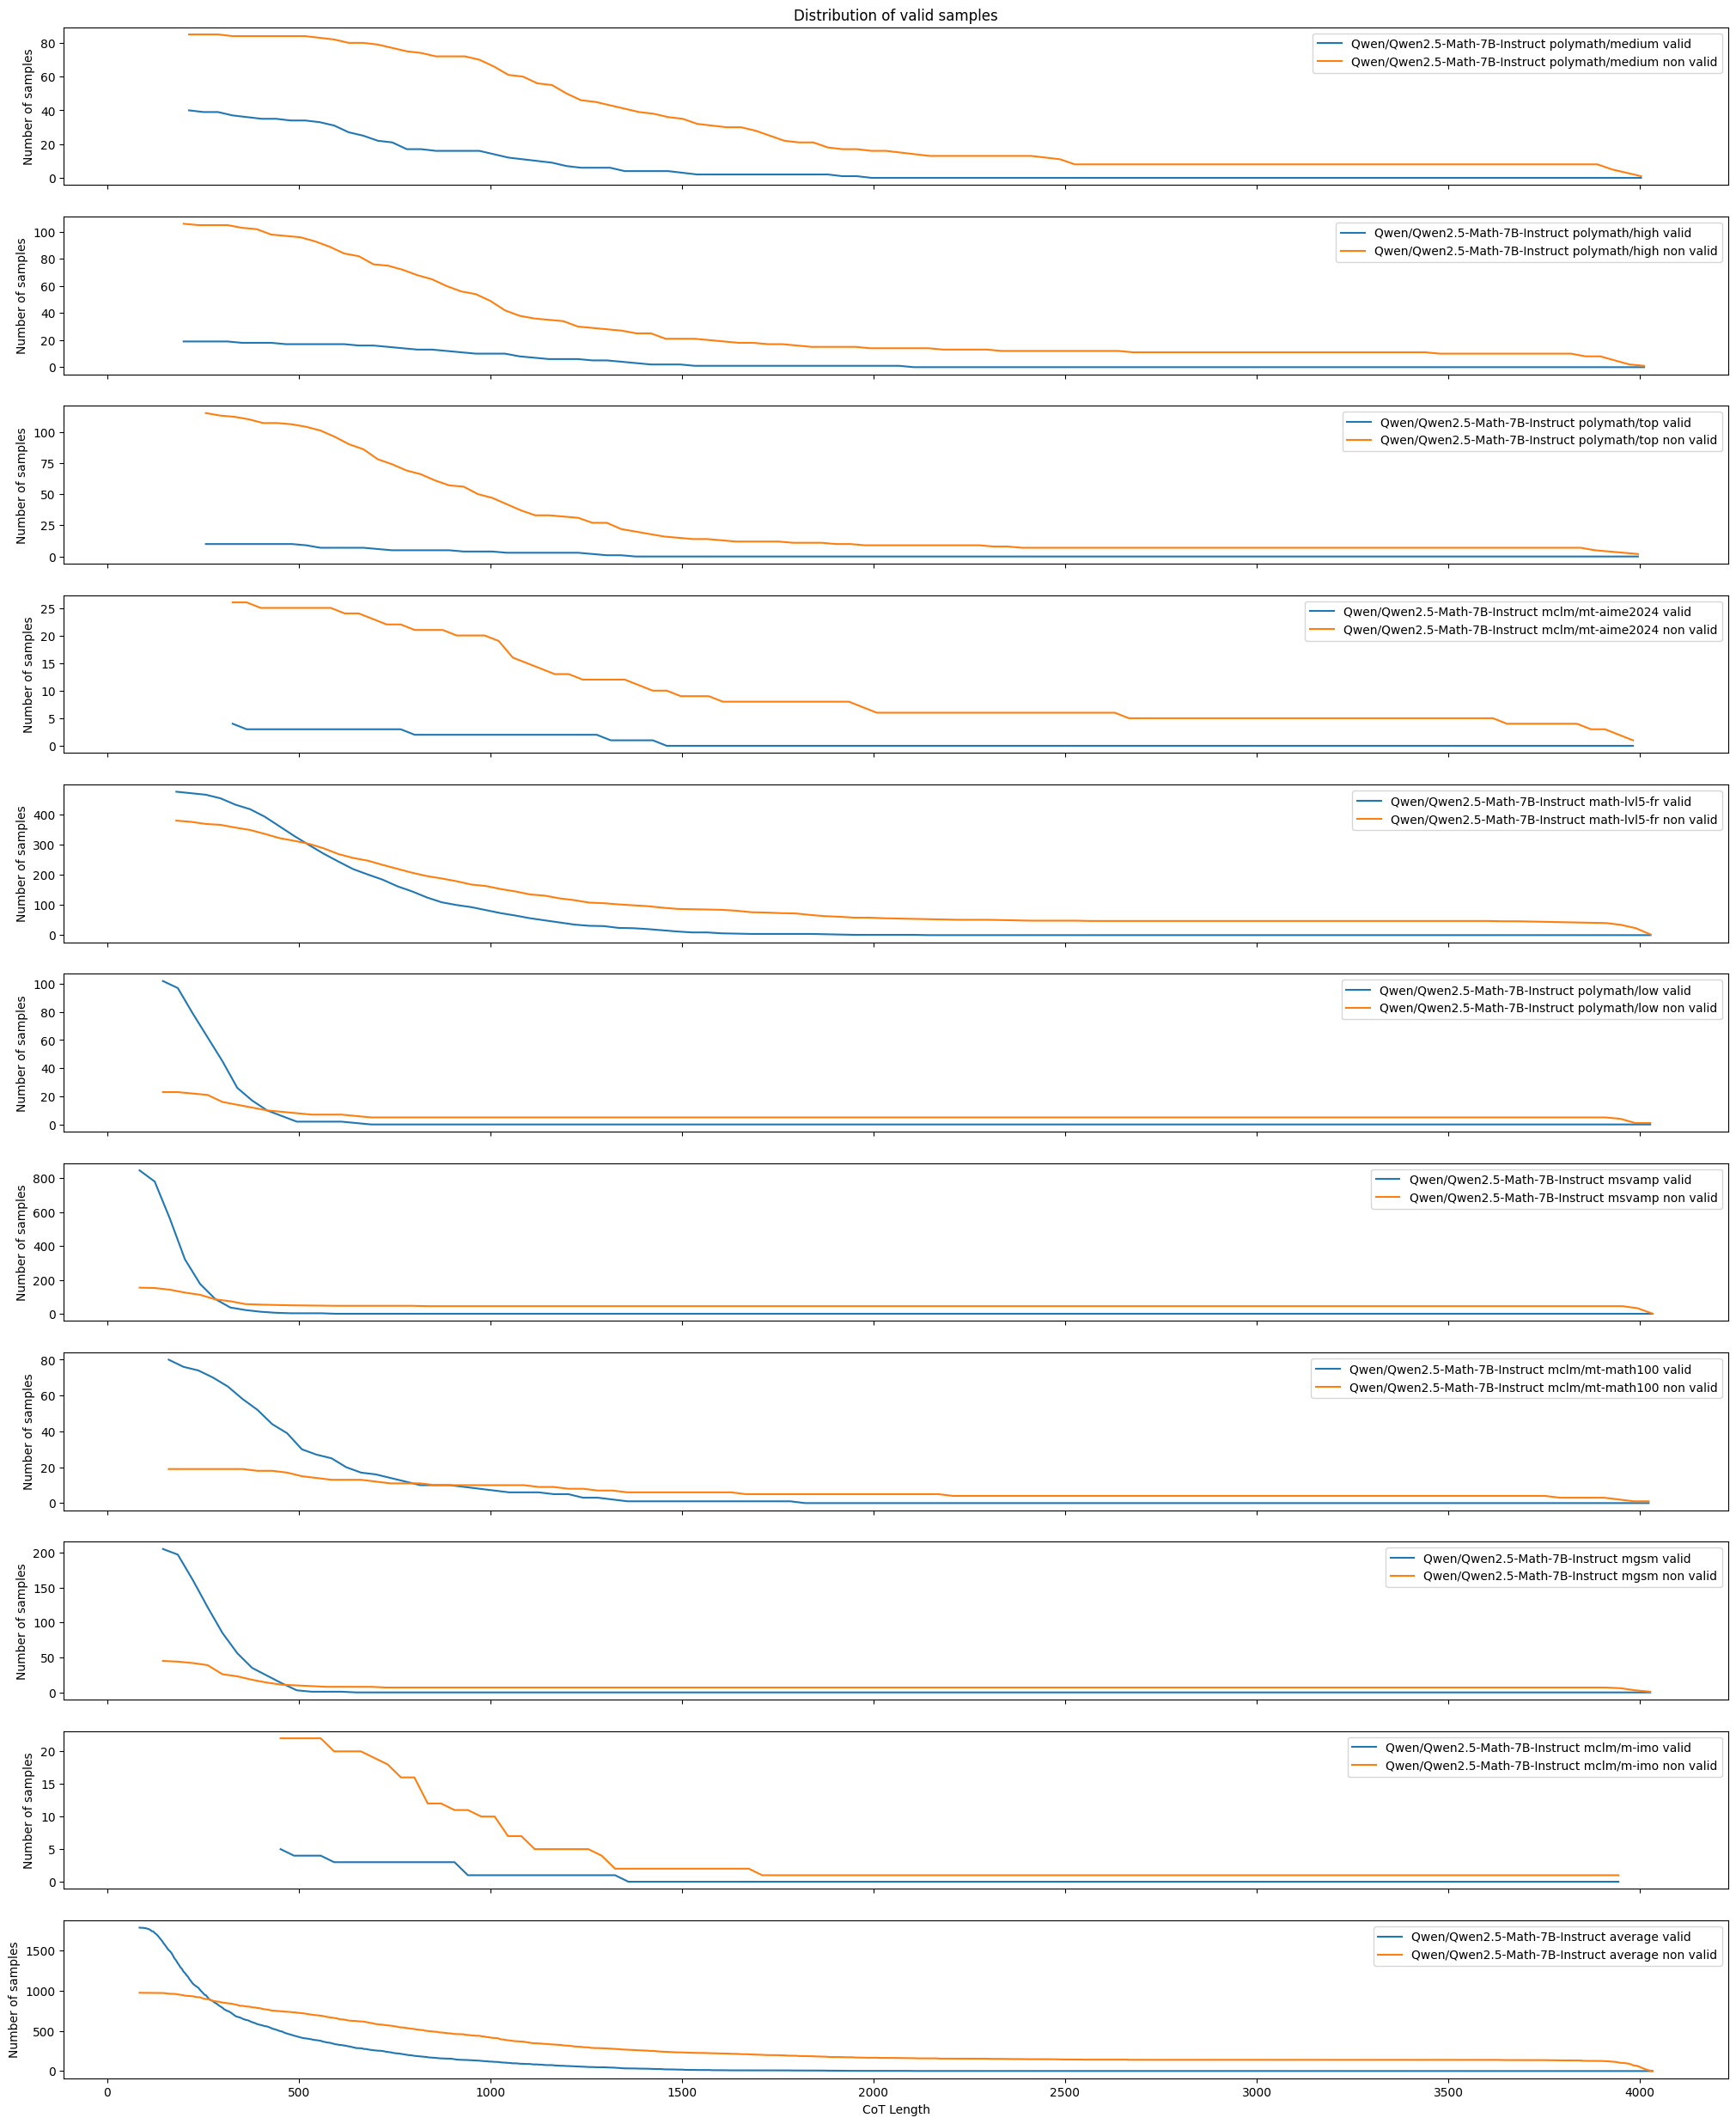

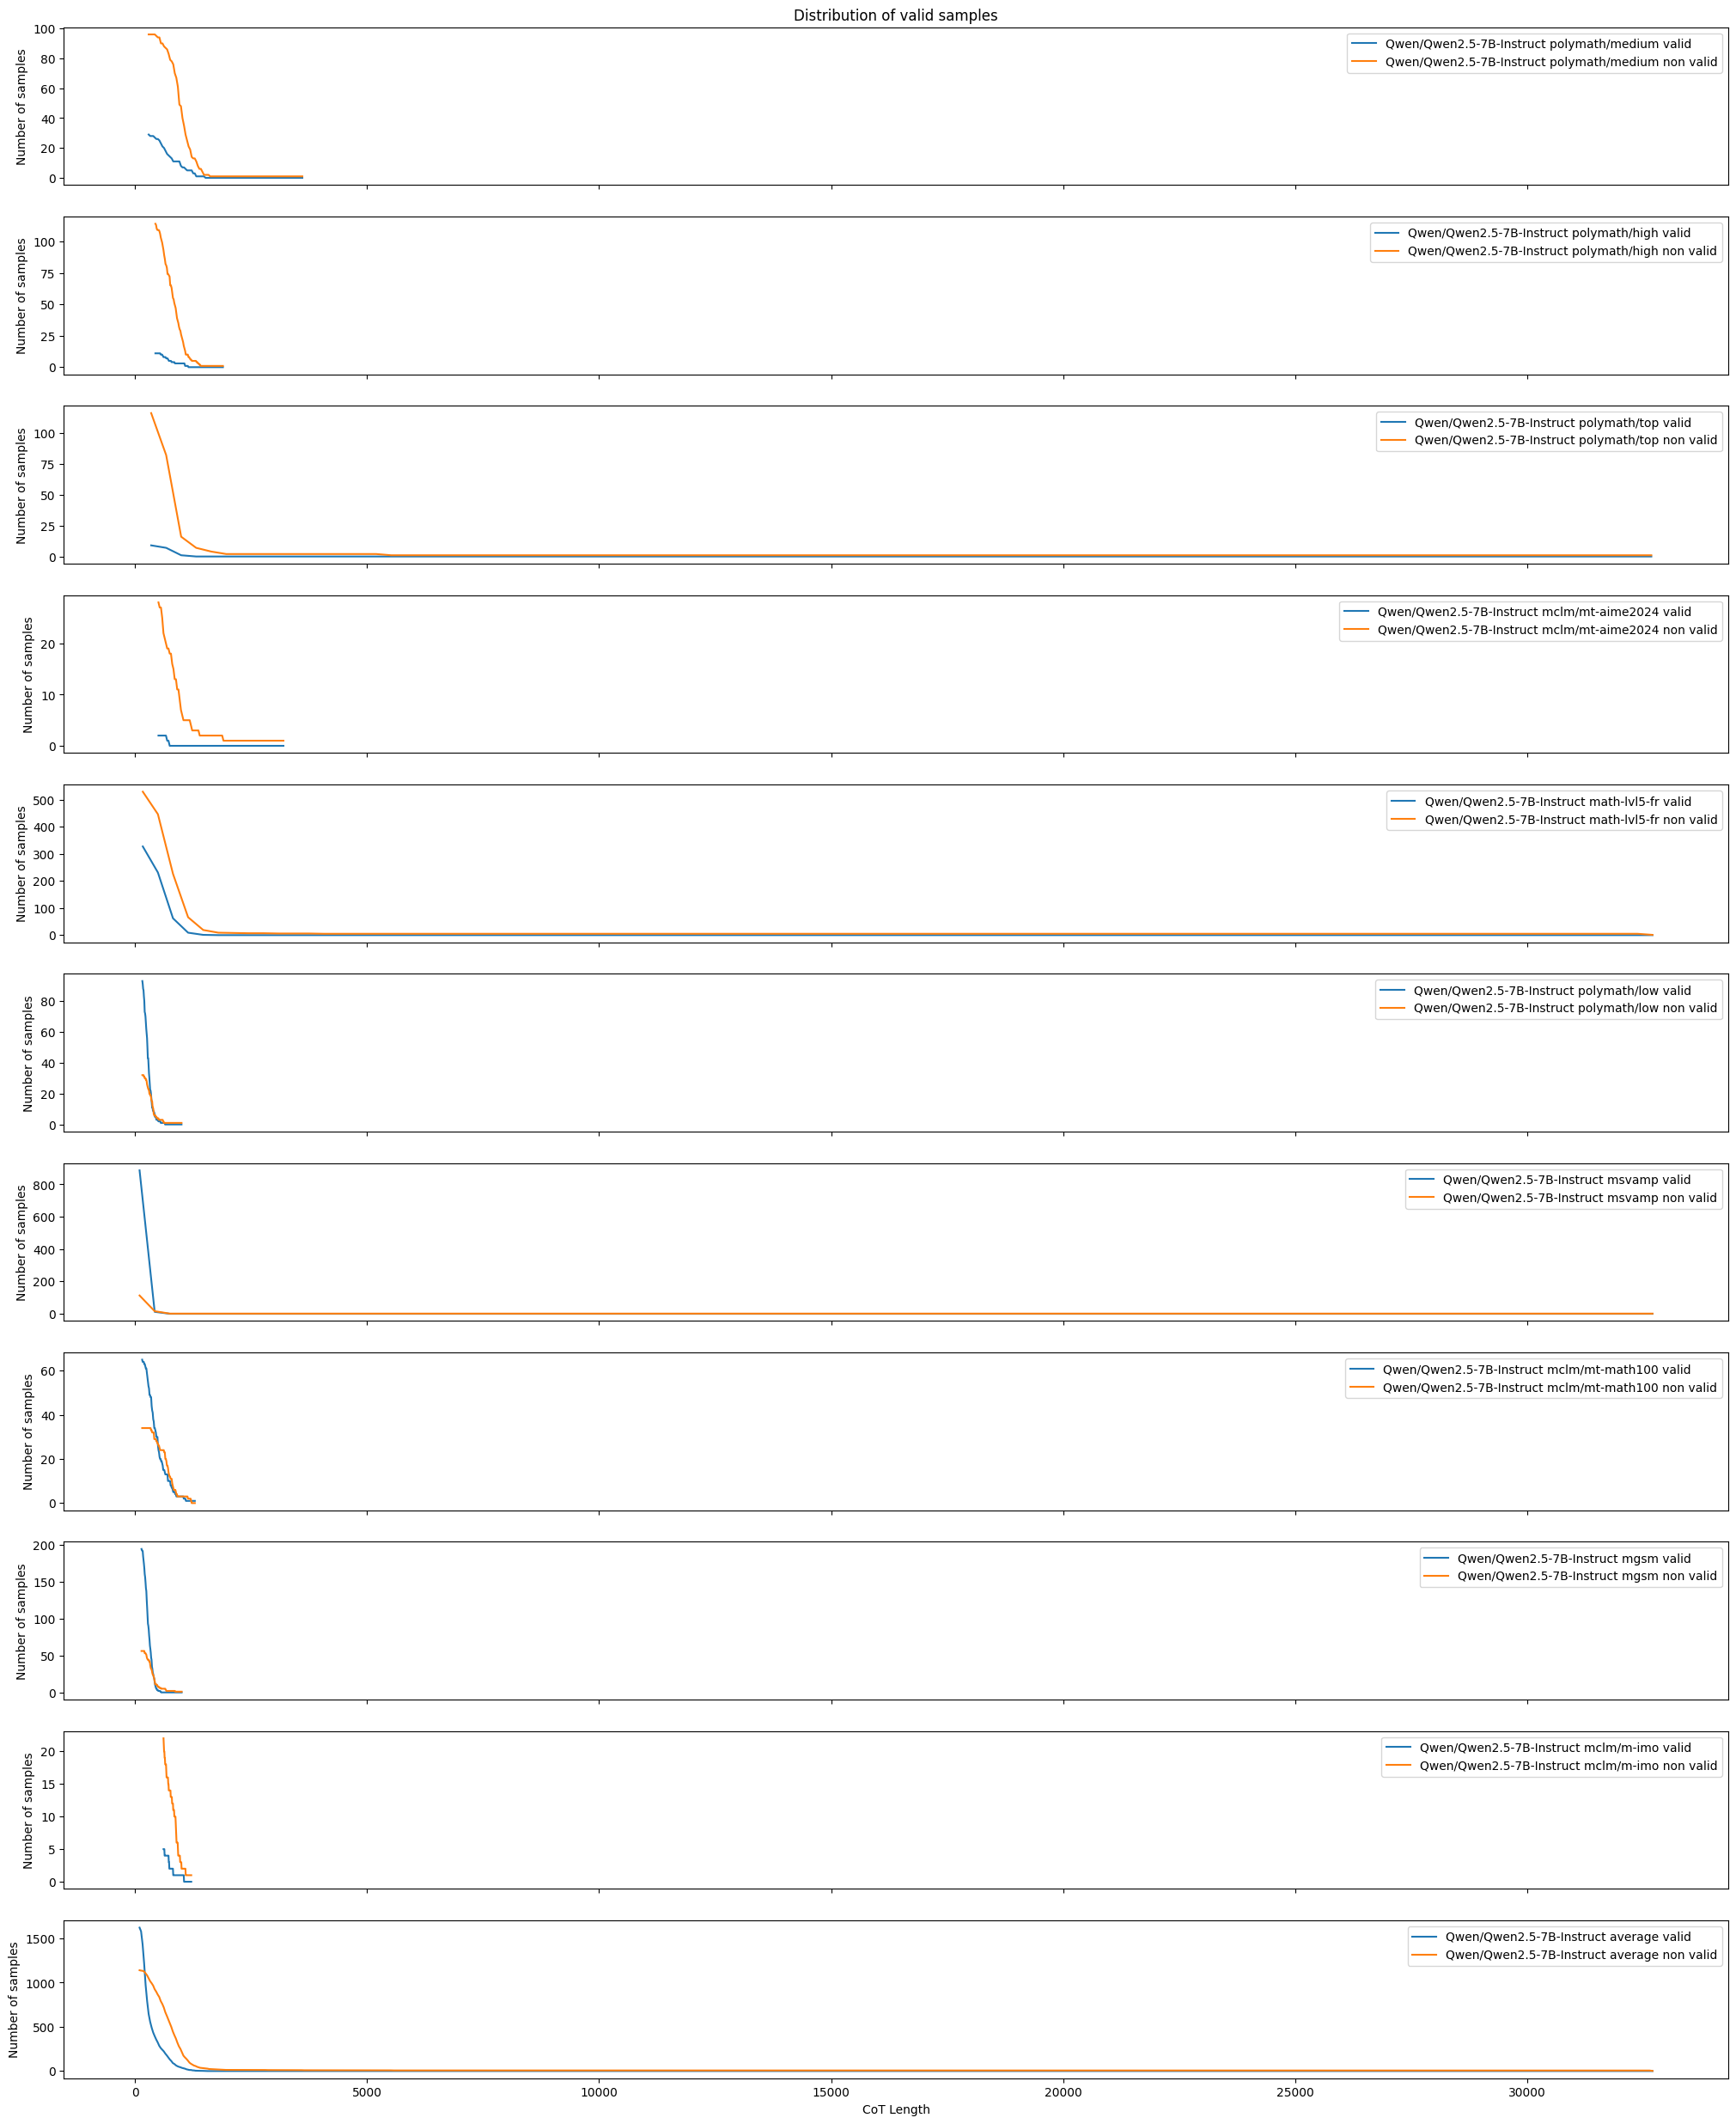

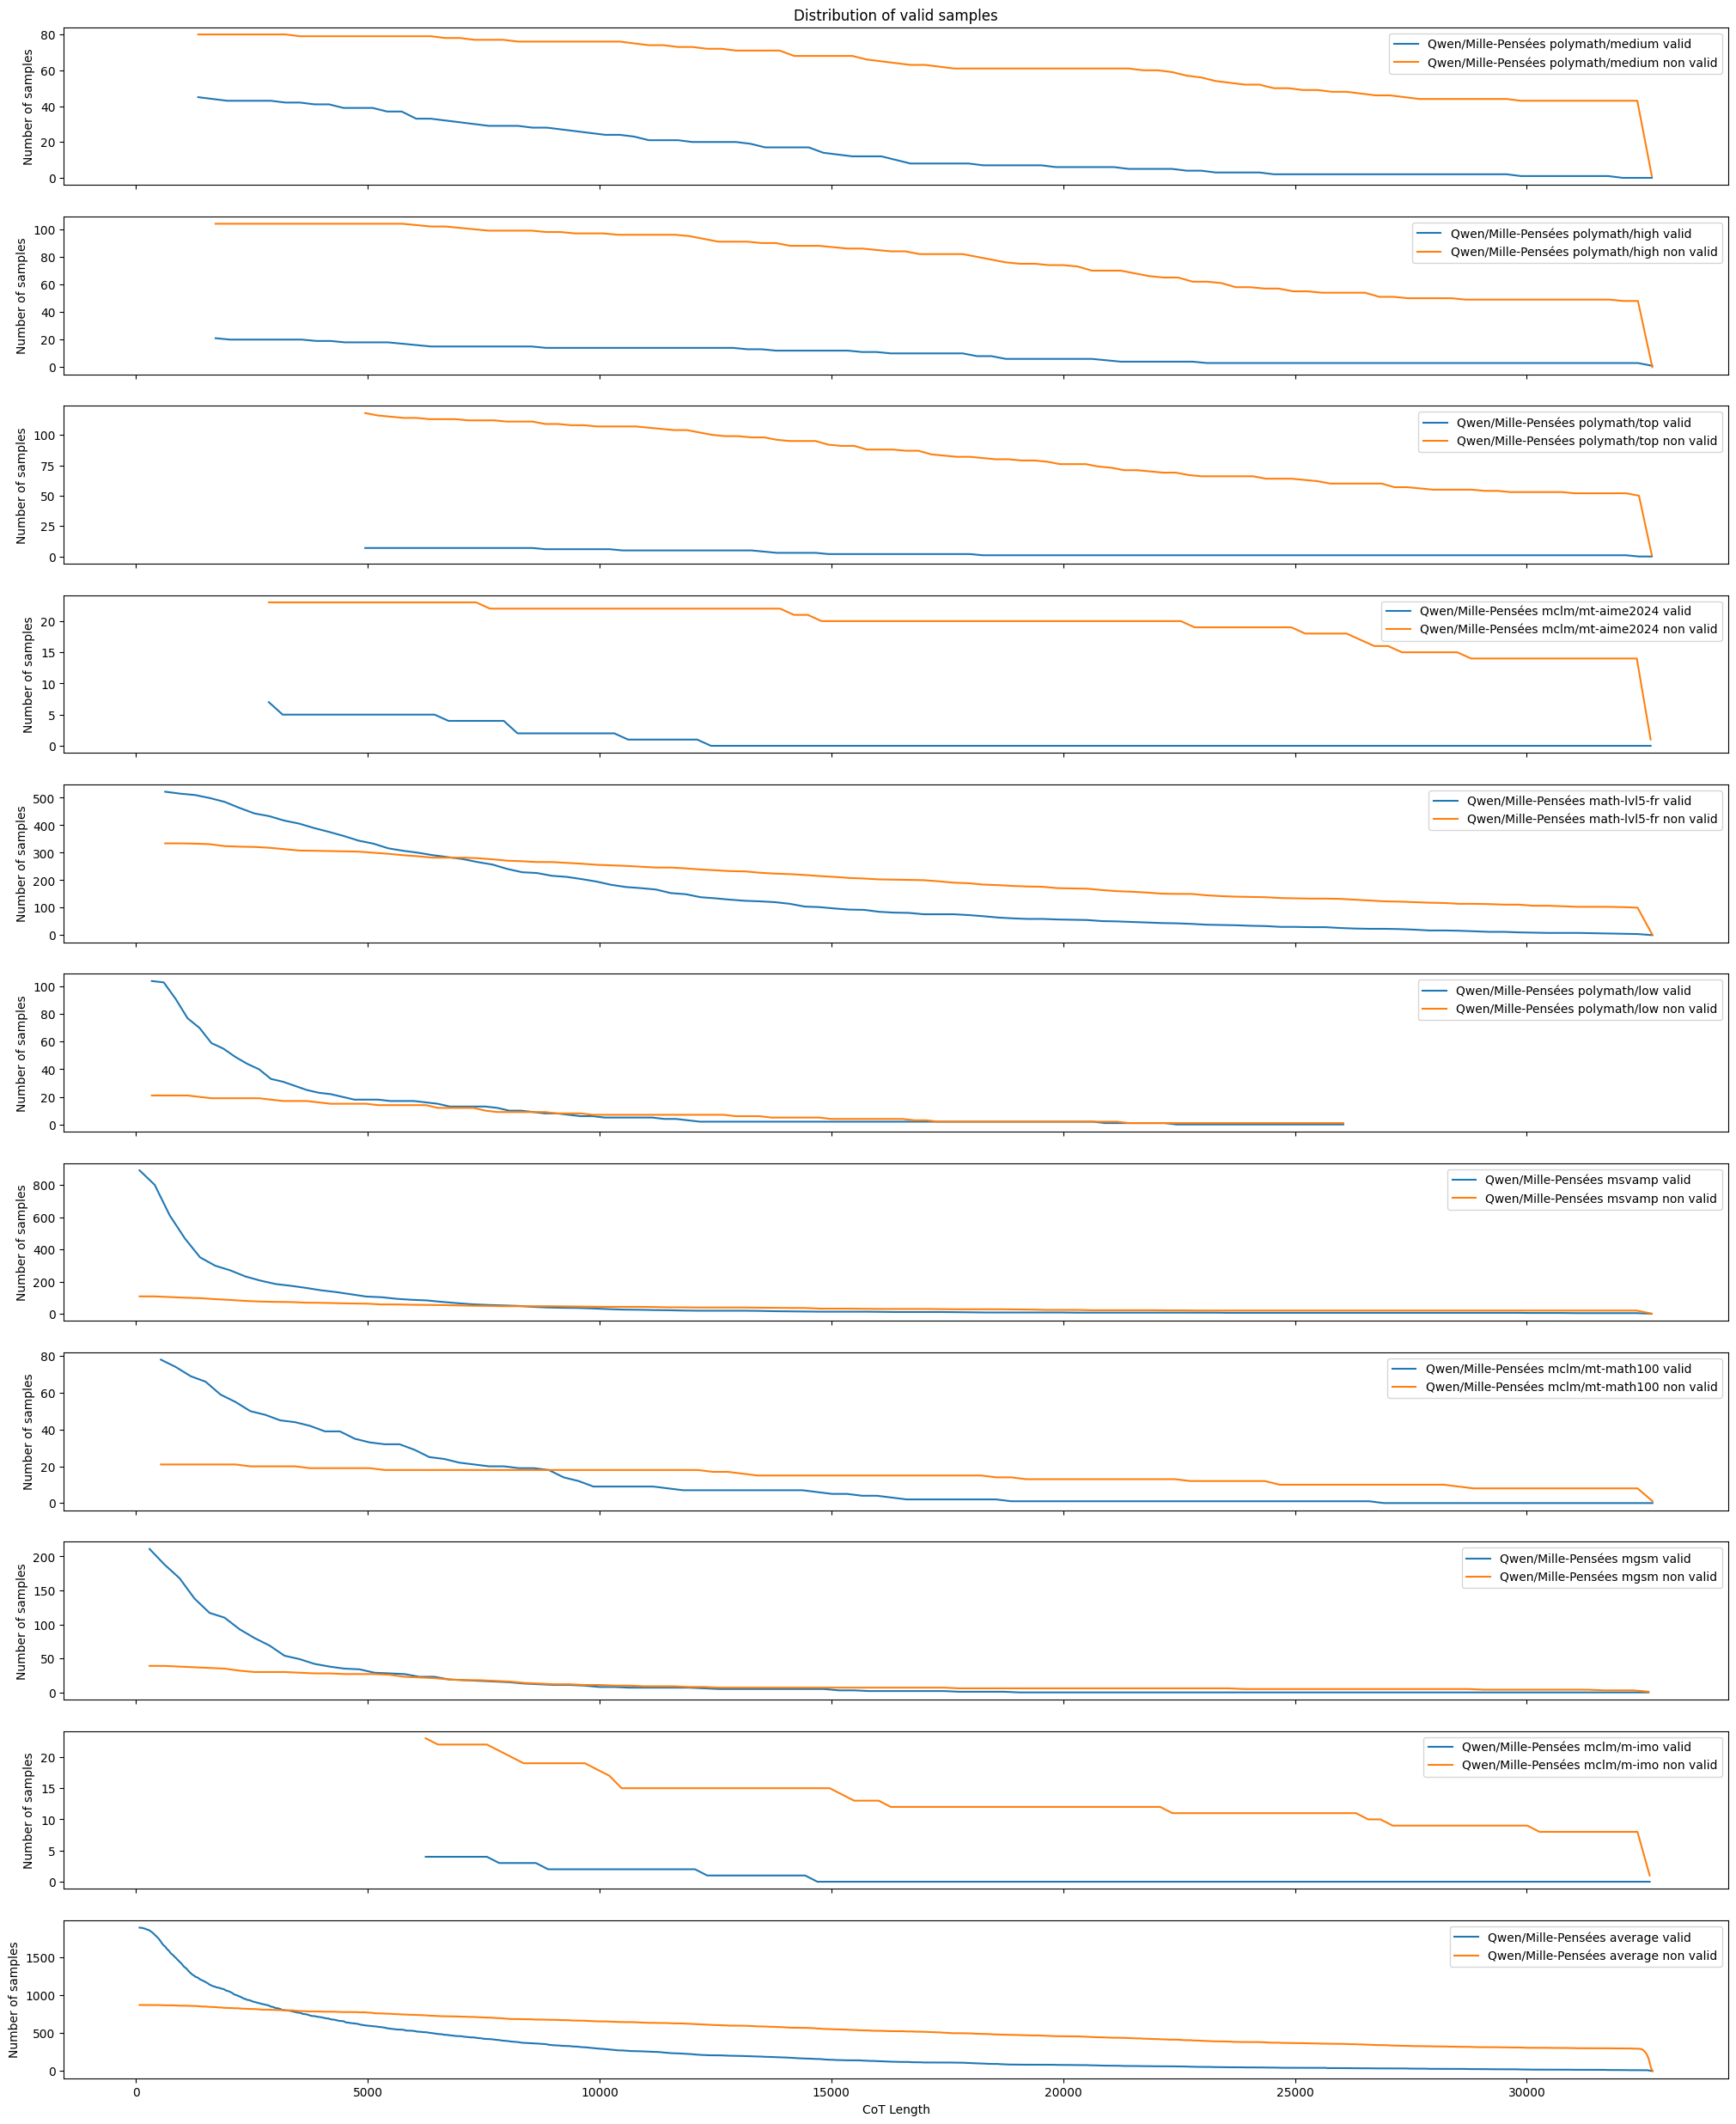

In [8]:
for model, result in results.items():
    fig, axs = plt.subplots(len(datasets)+1, figsize=(25,3*len(datasets)+1), sharex=True)
    axs[0].set_title("Distribution of valid samples")
    for i, dataset in enumerate(datasets):
        valid = []
        non_valid = []
        bins = np.histogram(
            [x["cot_length"] for x in result["samples"][dataset]],
            bins=100
        )[1]
        for x1, x2 in zip(bins, bins + [100000]):
            subset = [x["is_valid"] for x in result["samples"][dataset] if (x["cot_length"] >= x1 and x["cot_length"] < x2)]
            valid.append(sum(subset))
            non_valid.append(len(subset)-sum(subset))
        axs[i].plot(bins, valid, label=model+" "+dataset+" valid")
        axs[i].plot(bins, non_valid, label=model+" "+dataset+" non valid")
        axs[i].set_ylabel("Number of samples")
        axs[i].legend()
        
    bins = np.histogram(
        [x["cot_length"] for dataset_result in result["samples"].values() for x in dataset_result],
        bins=1000
    )[1]
    valid = []
    non_valid = []
    for x1, x2 in zip(bins, bins + [500000]):
        subset = [x["is_valid"] for dataset_result in result["samples"].values() for x in dataset_result if (x["cot_length"] >= x1 and x["cot_length"] < x2)]
        valid.append(sum(subset))
        non_valid.append(len(subset)-sum(subset))
    axs[-1].plot(bins, valid, label=model+" average valid")
    axs[-1].plot(bins, non_valid, label=model+" average non valid")
    axs[-1].set_xlabel("CoT Length")
    axs[-1].set_ylabel("Number of samples")
    axs[-1].legend()
    plt.savefig("valid.png")
    plt.show()
    

In [10]:
#HARDCODED EVAL RESULTS

n_models=3
datasets=["BBH", "MuSR", "MMLU-Pro", "Hellaswag"]

results = {
    "Qwen2.5-Math-7B-Instruct": {
        "accuracies": {
            "BBH": 0.4579,
            "MuSR": 0.3889,
            "MMLU-Pro": 0.2901,
            "Hellaswag": 0.4394,
        }
    },
    "Qwen2.5-7B-Instruct" : {
        "accuracies": {
            "BBH": 0.5504,
            "MuSR": 0.4299,
            "MMLU-Pro": 0.4466,
            "Hellaswag": 0.6204,
        }
    },
    "Mille-Pensées": {
        "accuracies": {
            "BBH": 0.5319,
            "MuSR": 0.4246,
            "MMLU-Pro": 0.4173,
            "Hellaswag": 0.6053,
        }
    },
}

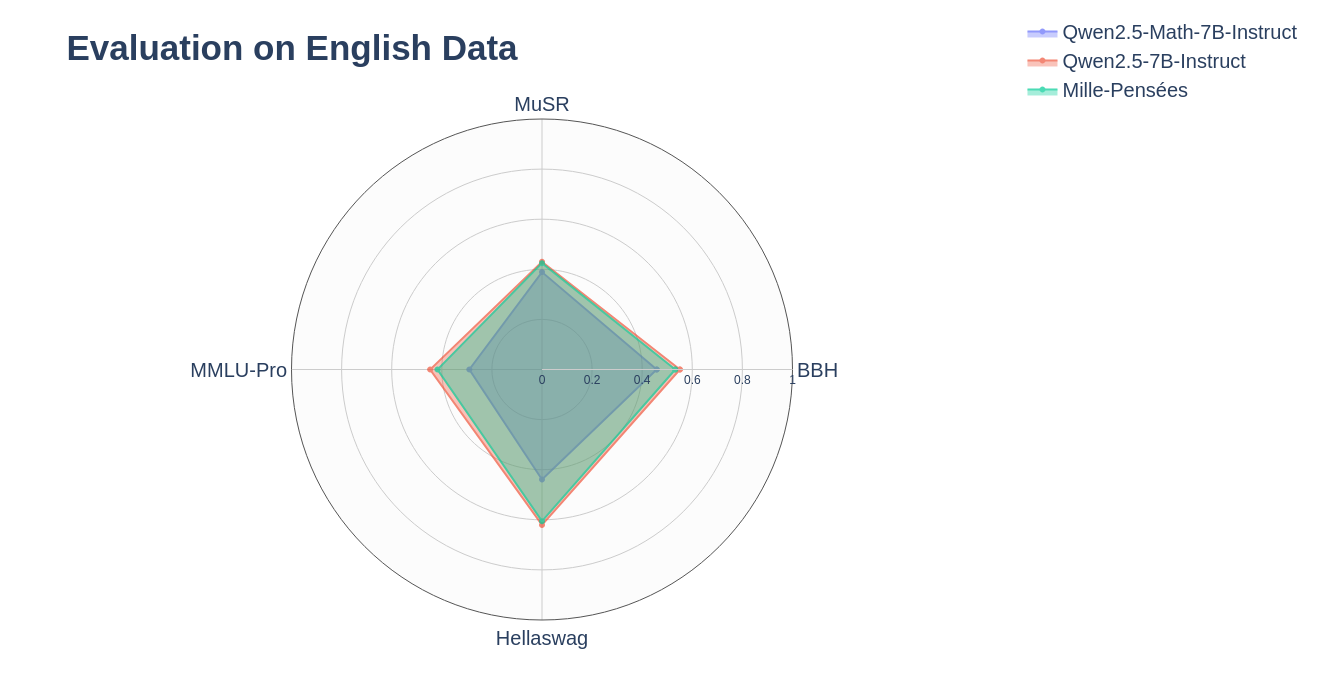

In [11]:
import plotly.graph_objects as go


fig = go.Figure()
for i, (model, result) in enumerate(results.items()):
    r = [result["accuracies"][dataset] if dataset in result["accuracies"] else 0.0 for dataset in datasets]
    r = list(r) + list([r[0]])
    fig.add_trace(go.Scatterpolar(
          r=r,
          theta=datasets + [datasets[0]],
        fill='toself',
          opacity=0.7,
          name=model.split("/")[-1]
    ))

fig.update_layout(
    width=1100,
    height=700,
    title="Evaluation on English Data",
    title_font_size=35,
    title_font_weight=1000,
    legend_font_size=20,
    legend_y=5000,
    legend_x=1000,
    polar=dict(
        bgcolor="#fcfcfc",
        angularaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#555",
            tickfont_size=20,
        ),
        radialaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#ccc",
            visible=True,
            range=[0, 1]
        )),
    showlegend=True
)

fig.show()